# EDA — diseases_and_symptoms.csv

- **Nguồn:** `Dataset/Data/diseases_and_symptoms.csv`
- **Kích thước:** 246,945 hàng × 378 cột (1 nhãn bệnh + 377 triệu chứng nhị phân)
- **Nhãn:** Có cột `diseases` làm nhãn bệnh (773 lớp).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
df = pd.read_csv("../Data/diseases_and_symptoms.csv")

print('Shape:', df.shape)
print('Columns (first 10):', df.columns.tolist()[:10], '...')
print('Has disease label:', 'diseases' in df.columns)
print('\nDtypes (first 10):')
print(df.dtypes.head(10))

df.head()

Shape: (246945, 378)
Columns (first 10): ['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness'] ...
Has disease label: True

Dtypes (first 10):
diseases                              str
anxiety and nervousness             int64
depression                          int64
shortness of breath                 int64
depressive or psychotic symptoms    int64
sharp chest pain                    int64
dizziness                           int64
insomnia                            int64
abnormal involuntary movements      int64
chest tightness                     int64
dtype: object


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Kiểm tra dữ liệu và missing values
missing = df.isnull().sum()
missing_sum = missing.sum()

if missing_sum == 0:
    print('Không có missing values.')
else:
    print(f'Tổng missing values: {missing_sum}')
    print(missing[missing > 0])

Không có missing values.


In [6]:
# Kiểm tra trùng lặp
dup_rows = df.duplicated().sum()
print(f'Số hàng trùng lặp: {dup_rows}')
if dup_rows > 0:
    print(df[df.duplicated(keep=False)].head())

Số hàng trùng lặp: 57298
          diseases  anxiety and nervousness  depression  shortness of breath  \
7   panic disorder                        0           0                    0   
8   panic disorder                        1           0                    0   
11  panic disorder                        1           0                    0   
13  panic disorder                        1           0                    0   
20  panic disorder                        0           0                    1   

    depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
7                                  1                 0          0         1   
8                                  1                 0          1         1   
11                                 1                 0          1         0   
13                                 1                 0          0         0   
20                                 1                 0          0         1   

    abnormal involu

In [7]:
# Giá trị triệu chứng chỉ nên là 0 hoặc 1 (giá trị vô lý)
symptom_cols = [c for c in df.columns if c != 'diseases']
invalid = df[symptom_cols].apply(lambda x: ~x.isin([0, 1])).sum().sum()

if invalid == 0:
    print('Tất cả giá trị triệu chứng đều nằm trong {0, 1}. Không có giá trị vô lý.')
else:
    print(f'Số giá trị vô lý: {invalid}')
    print(df.loc[(df[symptom_cols] < 0).any(axis=1) | (df[symptom_cols] > 1).any(axis=1)].head())

Tất cả giá trị triệu chứng đều nằm trong {0, 1}. Không có giá trị vô lý.


Số lớp bệnh: 773
diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
hypoglycemia                      1215
conjunctivitis due to allergy     1215
vaginal cyst                      1215
esophagitis                       1215
peripheral nerve disorder         1215
gastrointestinal hemorrhage       1214
diverticulitis                    1214
acute bronchitis                  1213
infectious gastroenteritis        1212
pneumonia                         1212
fungal infection of the hair      1212
sprain or strain                  1212
spontaneous abortion              1212
gout                              1211
marijuana abuse                   1210
Name: count, dtype: int64


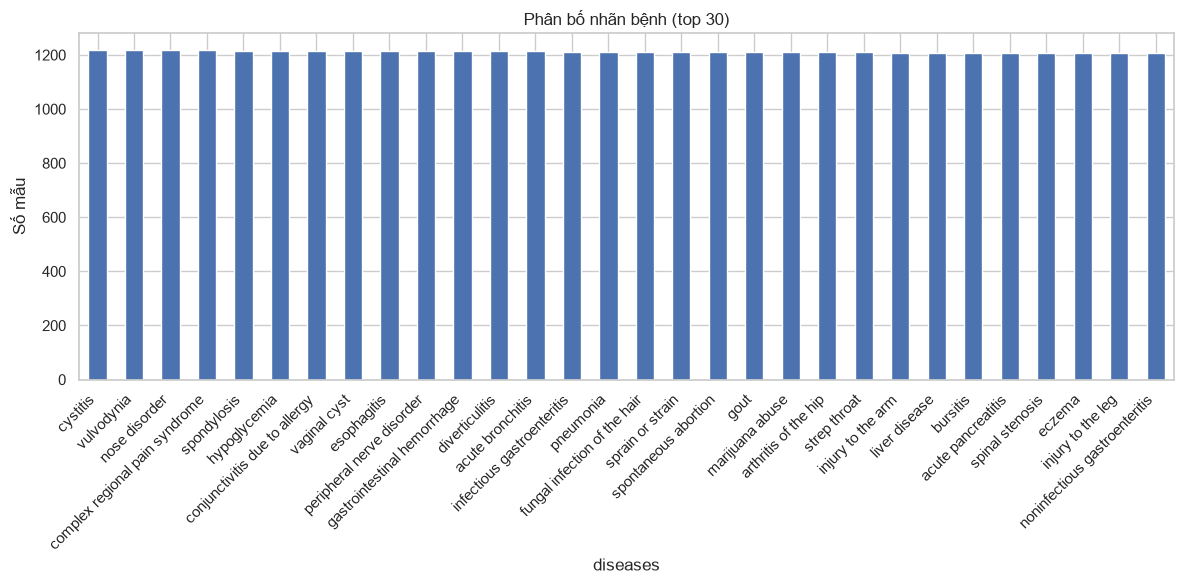

In [8]:
# Phân bố nhãn bệnh (diseases)
label_counts = df['diseases'].value_counts()
print('Số lớp bệnh:', label_counts.shape[0])
print(label_counts.head(20))

plt.figure(figsize=(12, 6))
label_counts.head(30).plot(kind='bar')
plt.title('Phân bố nhãn bệnh (top 30)')
plt.ylabel('Số mẫu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Có 377 triệu chứng. Lấy top 50 triệu chứng có variance cao để tính correlation.


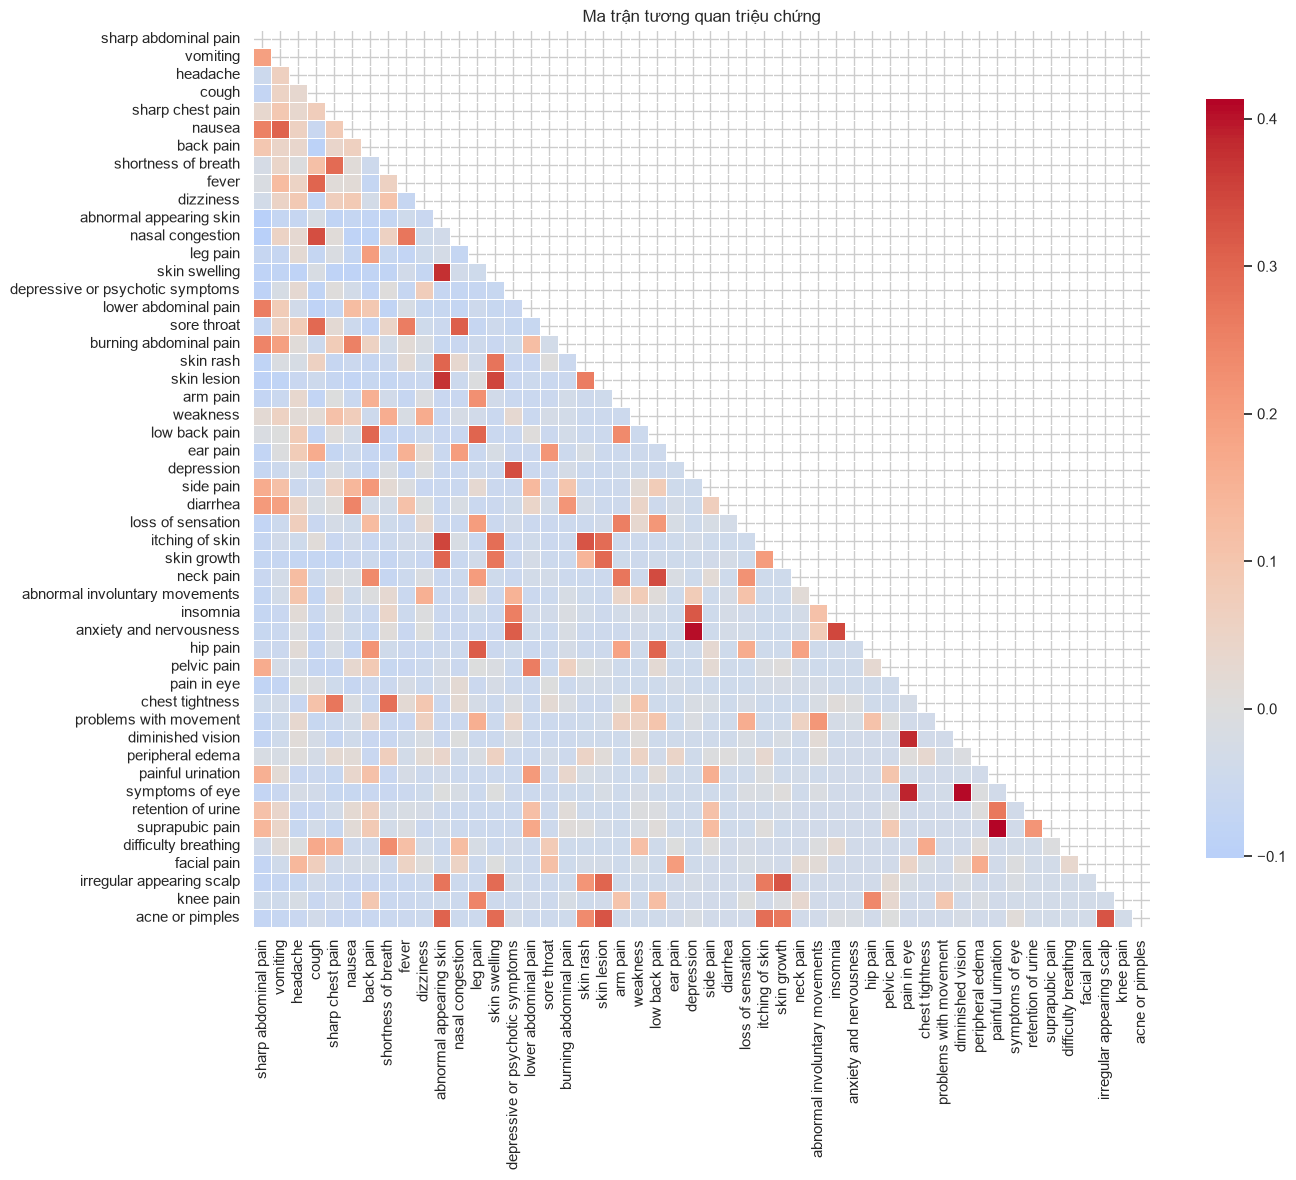

In [9]:
# Ma trận tương quan
symptom_df = df[symptom_cols]

if symptom_df.shape[1] > 100:
    print(f'Có {symptom_df.shape[1]} triệu chứng. Lấy top 50 triệu chứng có variance cao để tính correlation.')
    variance = symptom_df.var()
    top_cols = variance.nlargest(50).index.tolist()
    corr = symptom_df[top_cols].corr()
else:
    corr = symptom_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 12))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Ma trận tương quan triệu chứng')
plt.tight_layout()
plt.show()

- **Missing values:** 0 — dữ liệu không có giá trị thiếu.
- **Trùng lặp:** 57,298 hàng trùng lặp hoàn toàn (~23%). Cần xem xét có phải nhiễu hay mẫu hợp lệ trước khi loại bỏ.
- **Giá trị vô lý:** 0 — tất cả triệu chứng nằm trong {0, 1}, không có outlier vượt ngoài khoảng sinh học cho dữ liệu nhị phân.
- **Phân bố nhãn:** Các lớp có tần suất khá đồng đều (~1,200–1,220 mẫu/lớp ở top), không quá lệch cực đoan nhưng số lớp lớn (773) gây thách thức cho phân loại.
- **Ma trận tương quan:** Nếu chọn top 50 triệu chứng có variance cao, cần kiểm tra các cặp triệu chứng tương quan mạnh (>0.7) để tránh đa cộng tuyến khi huấn luyện mô hình.